# DSN Preprocessing — Daily RMS and Phase Scintillation

This notebook combines the large-scale Doppler RMS diagnostics and the phase scintillation preprocessing pipeline into a single workflow.

---

## Workflow

### SECTION 1 — Daily Doppler RMS Diagnostics

1. Load DSN Doppler data
2. Apply quality filtering
3. Compute daily Doppler RMS
4. Merge with solar elongation (SEP)
5. Compare against DSN solar scintillation model
6. Add seasonal tropospheric model
7. Generate large-scale diagnostic plots

---

### SECTION 2 — Phase Scintillation Window Construction

This notebook converts Doppler residuals into phase fluctuations and computes band-limited phase scintillation using a spectral (PSD-based) method.

---

## Method

The processing steps are:

1. Load filtered Doppler data
2. Convert Doppler frequency → phase:
   
   φ(t) = 2π ∫ f(t) dt

3. Segment data into overlapping time windows:
   - window length: 20 minutes
   - step size: 10 minutes

4. For each window:
   - compute power spectral density (Welch method)
   - integrate PSD over the scintillation band:
     
     3×10⁻⁴ Hz to 3×10⁻² Hz

5. Compute band-limited phase RMS for each window

---

## Output

This notebook produces:

- `phase_windows_<year>.csv`

Each row represents a time window with:

- phase RMS (rad)
- number of samples
- window timing

This dataset is the core input for CIR and CME detection.
---

## Outputs

This notebook produces:

- `daily_metrics_<year>.csv`
- `phase_windows_<year>.csv`

These outputs form the input to the CIR and CME detection pipeline.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ============================================================
# YEAR SELECTION
# ============================================================

YEAR = 2010

import importlib

settings = importlib.import_module(f"config.settings_{YEAR}")

for name in dir(settings):
    if not name.startswith("_"):
        globals()[name] = getattr(settings, name)

print(f"Loaded settings for YEAR = {YEAR}")

from src.io_utils import (
    load_dsn_data,
    load_horizons_daily_sep,
    remove_known_bad_tracking_intervals,
)

from src.doppler_utils import (
    prepare_daily_rms_table,
    print_daily_summary,
    add_seasonal_troposphere_model,
)

from src.phase_utils import (
    compute_phase_rms_windows,
    print_phase_summary,
)

from src.plot_utils import (
    plot_daily_rms_vs_sep,
    plot_phase_scintillation_time_series,
)

debug= True
save_file = True

Loaded settings for YEAR = 2010


# SECTION 1 — Daily Doppler RMS Diagnostics

In [2]:
horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)
df = remove_known_bad_tracking_intervals(
    df,
    year=YEAR,
    time_col="UTC_time",
    verbose=True,
)
if debug:

    print("Horizons rows:", len(horizons_daily))
    print(
        "Horizons range:",
        horizons_daily["day"].min(),
        "→",
        horizons_daily["day"].max(),
    )

    print("DSN rows:", len(df))
    print(
        "DSN range:",
        df["UTC_time"].min(),
        "→",
        df["UTC_time"].max(),
    )

[QC] No known bad tracking intervals for 2010
Horizons rows: 365
Horizons range: 2010-01-01 00:00:00 → 2010-12-31 00:00:00
DSN rows: 867761
DSN range: 2010-01-01 09:37:22.814000 → 2010-12-30 12:39:54.533000


In [3]:
# ============================================================
# LOAD HORIZONS + DSN DATA
# ============================================================

horizons_daily = load_horizons_daily_sep(HORIZONS_FILE)

df = load_dsn_data(
    DOPPLER_FILE,
    valid_only=USE_VALID_FLAG,
    min_elev_deg=MIN_ELEV_DEG,
    max_abs_doppler_hz=MAX_ABS_DOPPLER_HZ,
)

# ============================================================
# APPLY KNOWN BAD DSN TRACKING INTERVAL QC
# ============================================================

from src.io_utils import remove_known_bad_tracking_intervals



# ------------------------------------------------------------
# QC CHECK
# ------------------------------------------------------------

print("\nAfter known-bad interval QC:")
print("Rows entering processing:", len(df))
print("Date range:", df["UTC_time"].min(), "→", df["UTC_time"].max())
print("Max |doppler|:", df["doppler"].abs().max())
print("Frac |doppler| > 0.25:", (df["doppler"].abs() > 0.25).mean())

check_bad = df[
    (df["UTC_time"] >= "2014-05-20") &
    (df["UTC_time"] <= "2014-05-31")
]

print("Rows inside removed bad interval:", len(check_bad))

if debug:
    print("Horizons rows:", len(horizons_daily))
    print(
        "Horizons range:",
        horizons_daily["day"].min(),
        "→",
        horizons_daily["day"].max(),
    )

    print("DSN rows:", len(df))
    print(
        "DSN range:",
        df["UTC_time"].min(),
        "→",
        df["UTC_time"].max(),
    )


After known-bad interval QC:
Rows entering processing: 867761
Date range: 2010-01-01 09:37:22.814000 → 2010-12-30 12:39:54.533000
Max |doppler|: 0.299848437
Frac |doppler| > 0.25: 0.00019590647655287572
Rows inside removed bad interval: 0
Horizons rows: 365
Horizons range: 2010-01-01 00:00:00 → 2010-12-31 00:00:00
DSN rows: 867761
DSN range: 2010-01-01 09:37:22.814000 → 2010-12-30 12:39:54.533000


In [4]:
daily_df = prepare_daily_rms_table(
    dsn_df=df,
    horizons_daily=horizons_daily,
    f_carrier_hz=F_CARRIER,
    c_mps=C,
    T_int_sec=T_INT,
    C_band=C_BAND,
    resample_rule=RESAMPLE_RULE,
    min_samples_per_day=MIN_SAMPLES_PER_DAY,
    smooth_days=SMOOTH_DAYS,
    add_tropo_diagnostic=False,
)

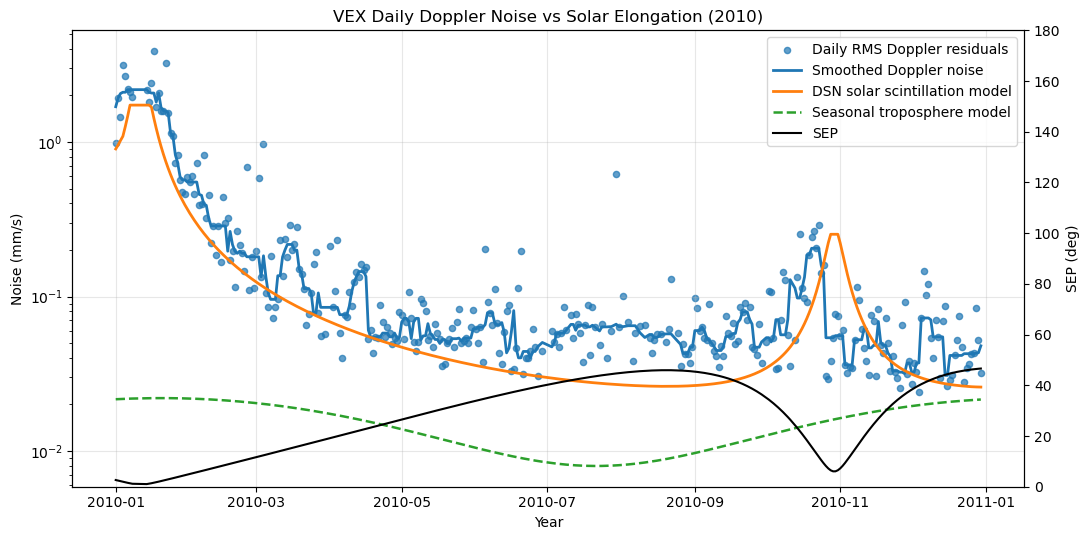

In [5]:
daily_df = add_seasonal_troposphere_model(
    daily_df=daily_df,
    amplitude_mm_s=TROPO_AMP,
    offset_mm_s=TROPO_OFFSET,
    phase_day=TROPO_PHASE_DAY,
    smooth_days=SMOOTH_DAYS,
)

fig, axes = plot_daily_rms_vs_sep(
    daily_df=daily_df,
    year=YEAR,
)

plt.show()

In [6]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    daily_csv = (
        OUTPUT_DIR
        / f"daily_metrics_{YEAR}.csv"
    )

    daily_df.to_csv(
        daily_csv,
        index=False,
    )

    print("Saved:", daily_csv)

Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/daily_metrics_2010.csv


In [7]:
if debug:

    print(daily_df.columns.tolist())

    display(daily_df.tail())

['day', 'doppler_rms_mm_s', 'n_60s_samples', 'elongation_deg', 'solar_model_mm_s', 'decimal_year', 'doppler_smooth_mm_s', 'solar_smooth_mm_s', 'doy', 'tropo_seasonal_mm_s', 'tropo_seasonal_smooth_mm_s']


,day,doppler_rms_mm_s,n_60s_samples,elongation_deg,solar_model_mm_s,decimal_year,doppler_smooth_mm_s,solar_smooth_mm_s,doy,tropo_seasonal_mm_s,tropo_seasonal_smooth_mm_s
331,2010-12-26,0.042642,438,46.2207,0.026071,2010.982888,0.042642,0.026071,360,0.036434,0.036434
332,2010-12-27,0.043255,435,46.3342,0.026011,2010.985626,0.042642,0.026011,361,0.036628,0.036628
333,2010-12-28,0.084529,433,46.4369,0.025957,2010.988364,0.042948,0.025984,362,0.036817,0.036722
334,2010-12-29,0.052680,431,46.5293,0.025908,2010.991102,0.043255,0.025957,363,0.037000,0.036817
335,2010-12-30,0.031980,97,46.6116,0.025865,2010.993840,0.047967,0.025932,364,0.037179,0.036908


# SECTION 2 — Phase Scintillation Window Construction

In [ ]:
# ============================================================
# SECTION 2 — Phase scintillation windows
# ============================================================

phase_csv = OUTPUT_DIR / f"phase_windows_{YEAR}.csv"

FORCE_RECOMPUTE_PHASE = True

if phase_csv.exists() and not FORCE_RECOMPUTE_PHASE:

    print("Loading cached phase windows:", phase_csv)

    windows_df = pd.read_csv(phase_csv)

    for col in ["start", "end", "mid"]:
        windows_df[col] = pd.to_datetime(windows_df[col])

else:

    print("Computing phase windows...")

    windows_df = compute_phase_rms_windows(
        df,
        time_col="UTC_time",
        doppler_col="doppler",
        dt_target_sec=DT_TARGET,
        window_min=WINDOW_MIN,
        step_min=STEP_MIN,
        min_samples=MIN_SAMPLES,
        f_low_hz=F_LOW,
        f_high_hz=F_HIGH,
    )

    geom = horizons_daily.set_index("day")

    windows_df["elongation_deg"] = np.interp(
        windows_df["mid"].astype("int64"),
        geom.index.astype("int64"),
        geom["elongation_deg"],
    )

    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    windows_df.to_csv(phase_csv, index=False)

    print("Saved:", phase_csv)

if debug:
    print_phase_summary(windows_df)
    display(windows_df.head())
    print(windows_df.columns.tolist())
    display(windows_df.tail())

fig, ax = plot_phase_scintillation_time_series(windows_df, year=YEAR)
plt.show()

if debug:

    valid = windows_df["phase_rms_rad"].dropna()

    print("Number of windows:", len(windows_df))
    print("Phase RMS min:", valid.min())
    print("Phase RMS median:", valid.median())
    print("Phase RMS max:", valid.max())

    print(
        "Median samples per window:",
        windows_df["n_samples"].median(),
    )

In [9]:
if save_file:

    OUTPUT_DIR.mkdir(
        parents=True,
        exist_ok=True,
    )

    phase_csv = (
        OUTPUT_DIR
        / f"phase_windows_{YEAR}.csv"
    )

    fig_path = (
        OUTPUT_DIR
        / f"phase_scintillation_{YEAR}.png"
    )

    windows_df.to_csv(
        phase_csv,
        index=False,
    )

    fig.savefig(
        fig_path,
        dpi=300,
        bbox_inches="tight",
    )

    print("Saved:", phase_csv)
    print("Saved:", fig_path)



Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_windows_2010.csv
Saved: /mnt/data/jhub/16-VenusExpres/dsn_multi_year/outputs/2010/phase_scintillation_2010.png


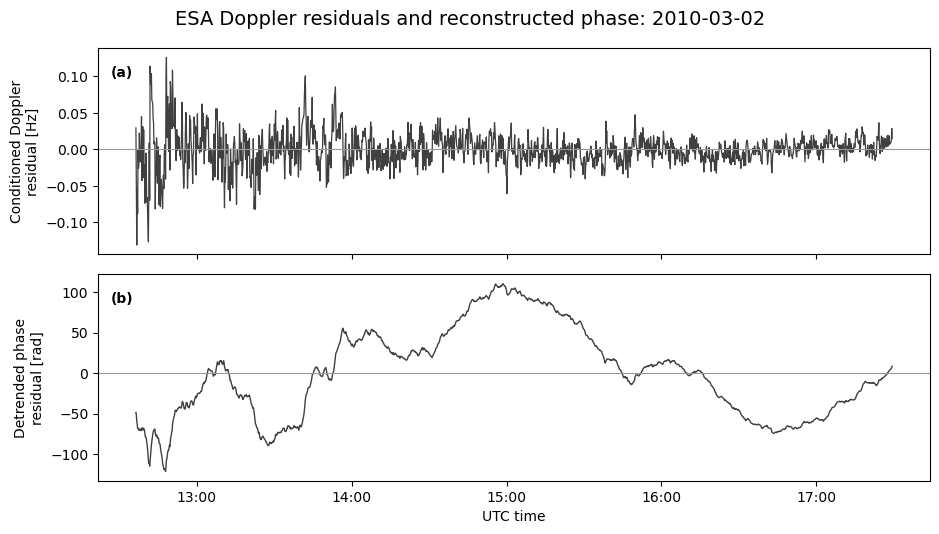

Saved: slide_7_doppler_phase_2010-03-02.png
Samples: 1760
Window: 2010-03-02 12:36:20 → 2010-03-02 17:29:30


In [71]:
# ============================================================
# Slide figure — Conditioned Doppler residual and detrended phase
# ============================================================

from scipy.signal import detrend
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd

from src.phase_utils import prepare_phase_input, add_phase_column

# ------------------------------------------------------------
# Select representative interval
# ------------------------------------------------------------

TARGET_DAY = "2010-03-02"
START_TIME = f"{TARGET_DAY} 05:40:00"
END_TIME   = f"{TARGET_DAY} 020:20:00"

start_time = pd.to_datetime(START_TIME)
end_time   = pd.to_datetime(END_TIME)

# ------------------------------------------------------------
# Prepare ESA Doppler and phase data
# ------------------------------------------------------------

df_phase = prepare_phase_input(
    df,
    time_col="UTC_time",
    doppler_col="doppler",
    dt_target_sec=DT_TARGET,
)

df_phase = add_phase_column(
    df_phase,
    doppler_col="doppler",
    dt_sec=DT_TARGET,
    out_col="phase_rad",
)

plot_df = df_phase[
    (df_phase.index >= start_time) &
    (df_phase.index < end_time)
].copy()

if plot_df.empty:
    raise ValueError("No data found in selected interval.")

# ------------------------------------------------------------
# Condition Doppler and phase
# ------------------------------------------------------------

plot_df["doppler_conditioned"] = detrend(
    plot_df["doppler"].to_numpy(),
    type="linear",
)

plot_df["phase_detrended_rad"] = detrend(
    plot_df["phase_rad"].to_numpy(),
    type="linear",
)

# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig, axes = plt.subplots(
    2,
    1,
    figsize=(9.5, 5.4),
    sharex=True,
)

ax0, ax1 = axes

# Panel (a): conditioned Doppler residual
ax0.plot(
    plot_df.index,
    plot_df["doppler_conditioned"],
    color="0.25",
    linewidth=0.9,
)

ax0.axhline(0, color="0.6", linewidth=0.8)
ax0.set_ylabel("Conditioned Doppler\nresidual [Hz]")
ax0.text(
    0.015,
    0.86,
    "(a)",
    transform=ax0.transAxes,
    fontweight="bold",
)


# Panel (b): detrended phase residual
ax1.plot(
    plot_df.index,
    plot_df["phase_detrended_rad"],
    color="0.25",
    linewidth=1.0,
)

ax1.axhline(0, color="0.6", linewidth=0.8)
ax1.set_ylabel("Detrended phase\nresidual [rad]")
ax1.set_xlabel("UTC time")
ax1.text(
    0.015,
    0.86,
    "(b)",
    transform=ax1.transAxes,
    fontweight="bold",
)

ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.suptitle(
    f"ESA Doppler residuals and reconstructed phase: {TARGET_DAY}",
    fontsize=14,
    y=0.98,
)

plt.tight_layout()

out_file = f"slide_7_doppler_phase_{TARGET_DAY}.png"

plt.savefig(
    out_file,
    dpi=300,
    bbox_inches="tight",
)

plt.show()

print("Saved:", out_file)
print("Samples:", len(plot_df))
print("Window:", plot_df.index.min(), "→", plot_df.index.max())